In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

from src.data.fetch_data import load_all_raw, STOCK_UNIVERSE
from src.data.preprocess import preprocess_all
from src.utils.metrics import evaluate
from src.models.prophet_model import (
    series_to_prophet_df, fit_prophet,
    predict_test_prophet, forecast_future_prophet,
    run_prophet_pipeline
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
print("Imports OK")

Imports OK


In [2]:
raw = load_all_raw()
processed = preprocess_all(raw, save=False)
print(f"Loaded {len(processed)} stocks")

INFO | Preprocessing HDFCBANK.NS …
INFO | Preprocessing ICICIBANK.NS …
INFO | Preprocessing TCS.NS …
INFO | Preprocessing INFY.NS …
INFO | Preprocessing SUNPHARMA.NS …
INFO | Preprocessing DRREDDY.NS …
INFO | Preprocessing HINDUNILVR.NS …
INFO | Preprocessing ITC.NS …
INFO | Preprocessing MARUTI.NS …
INFO | Preprocessing complete.


Loaded 9 stocks


In [3]:
TICKER = "TCS.NS"
train = processed[TICKER]["train"]
test  = processed[TICKER]["test"]

model = fit_prophet(train, changepoint_prior_scale=0.05)

pred = predict_test_prophet(model, test)

metrics = evaluate(test.values, pred.values, "Prophet", TICKER)
print(f"Metrics for {TICKER}:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

INFO | Chain [1] start processing
INFO | Chain [1] done processing


Metrics for TCS.NS:
  Ticker: TCS.NS
  Model: Prophet
  RMSE: 210.4783
  MAPE: 5.6986
  DirAcc: 50.0


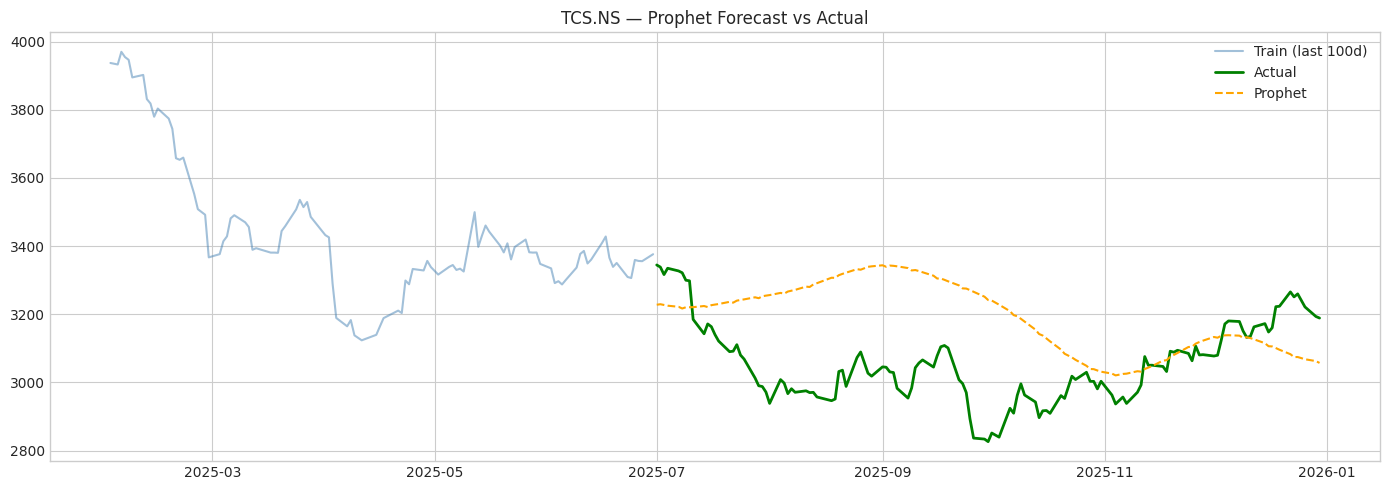

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train[-100:], label="Train (last 100d)", color="steelblue", alpha=0.5)
ax.plot(test, label="Actual", color="green", linewidth=2)
ax.plot(pred, label="Prophet", color="orange", linewidth=1.5, linestyle="--")
ax.set_title(f"{TICKER} — Prophet Forecast vs Actual")
ax.legend()
plt.tight_layout()
plt.show()

INFO | Chain [1] start processing
INFO | Chain [1] done processing


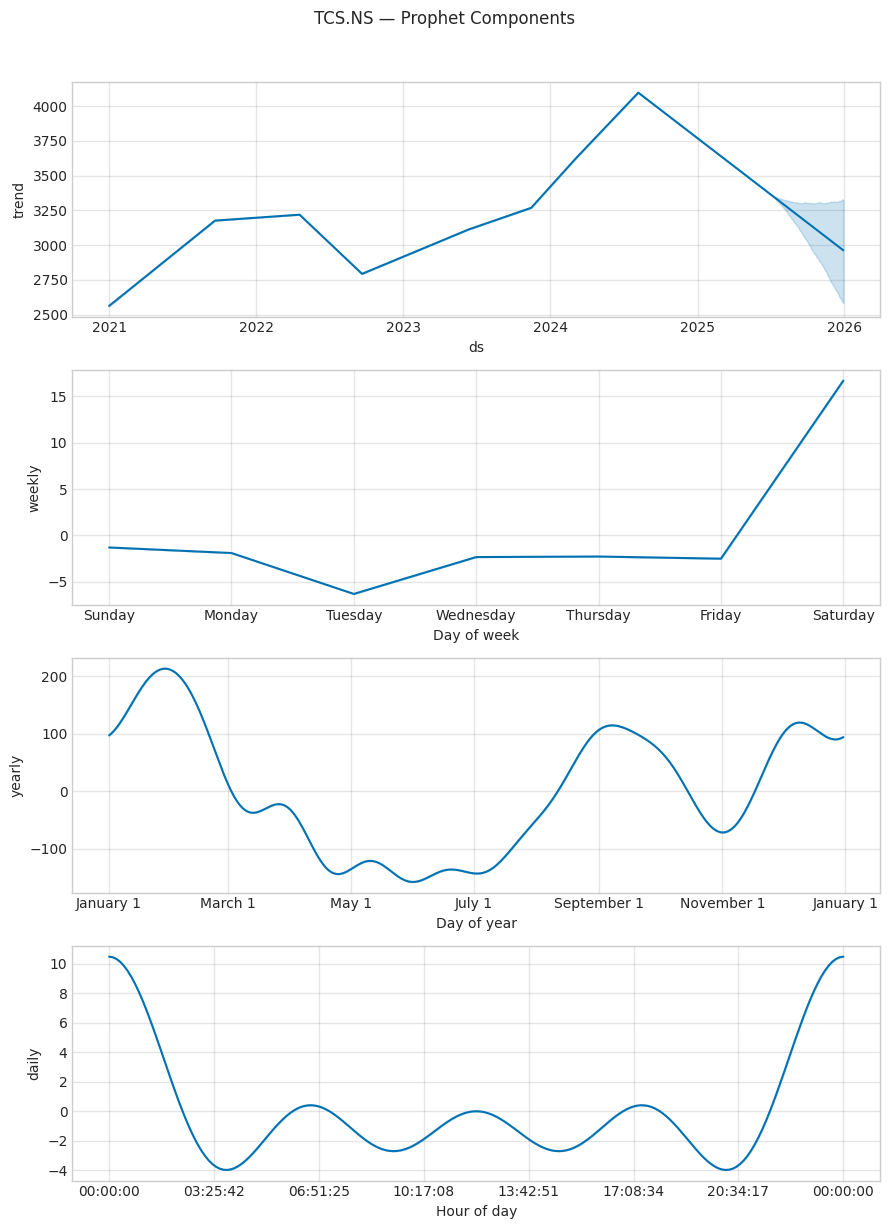

In [5]:
train_df = series_to_prophet_df(train)
m2 = Prophet(daily_seasonality=True, weekly_seasonality=True,
             yearly_seasonality=True, interval_width=0.95)
m2.fit(train_df)
future = m2.make_future_dataframe(periods=len(test) + 5, freq="B")
fc_full = m2.predict(future)

fig = m2.plot_components(fc_full)
plt.suptitle(f"{TICKER} — Prophet Components", y=1.02)
plt.tight_layout()
plt.show()

INFO | Chain [1] start processing
INFO | Chain [1] done processing



Prophet Forecast — TCS.NS — Next 5 Trading Days:
  2025-12-31: ₹2950.06  [₹2733.61 — ₹3184.50]
  2026-01-01: ₹2946.51  [₹2732.56 — ₹3176.50]
  2026-01-02: ₹2944.26  [₹2719.32 — ₹3157.86]
  2026-01-05: ₹2941.29  [₹2723.03 — ₹3153.06]
  2026-01-06: ₹2936.86  [₹2713.89 — ₹3151.54]


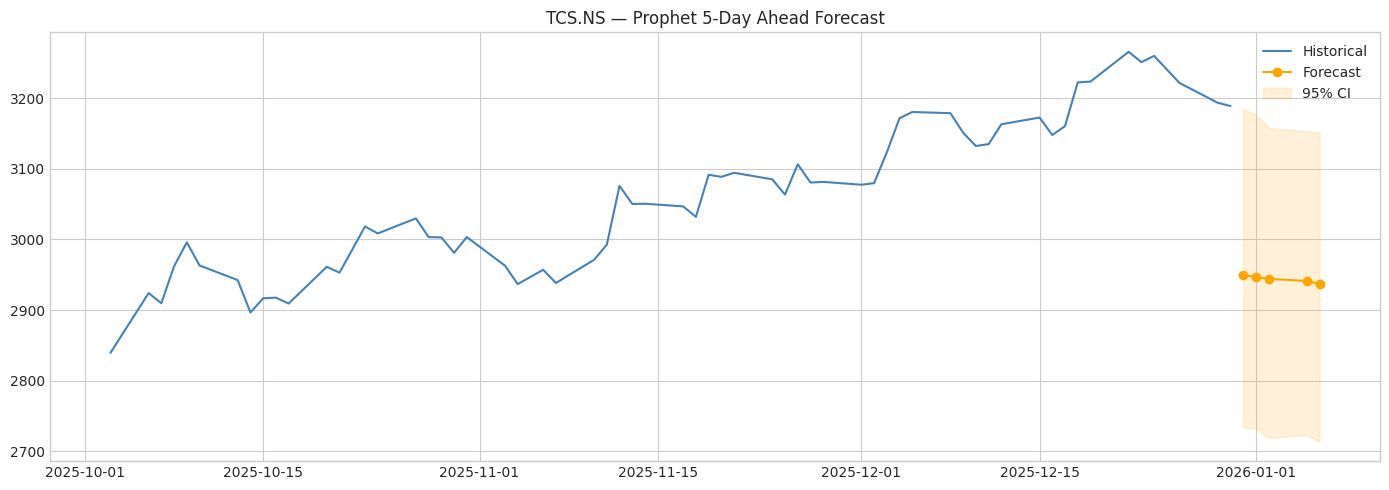

In [6]:
fc_vals, fc_lo, fc_hi = forecast_future_prophet(model, train, test, n_periods=5)
full = pd.concat([train, test])
future_dates = pd.bdate_range(start=full.index[-1] + pd.Timedelta(days=1), periods=5)

print(f"\nProphet Forecast — {TICKER} — Next 5 Trading Days:")
for d, v, lo, hi in zip(future_dates, fc_vals, fc_lo, fc_hi):
    print(f"  {d.date()}: ₹{v:.2f}  [₹{lo:.2f} — ₹{hi:.2f}]")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(full[-60:], label="Historical", color="steelblue")
ax.plot(future_dates, fc_vals, label="Forecast", color="orange", marker="o")
ax.fill_between(future_dates, fc_lo, fc_hi, color="orange", alpha=0.15, label="95% CI")
ax.set_title(f"{TICKER} — Prophet 5-Day Ahead Forecast")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
all_preds, all_fc, all_metrics = run_prophet_pipeline(processed, n_forecast=5)

metrics_df = pd.DataFrame(all_metrics)
print("\n── Prophet Results Across All Stocks ──")
print(metrics_df.to_string())
print(f"\nAvg MAPE: {metrics_df['MAPE'].mean():.2f}%")
print(f"Avg RMSE: {metrics_df['RMSE'].mean():.2f}")
print(f"Avg Dir Accuracy: {metrics_df['DirAcc'].mean():.1f}%")

INFO | Prophet | HDFCBANK.NS
INFO | Chain [1] start processing
INFO | Chain [1] done processing
INFO | Chain [1] start processing
INFO | Chain [1] done processing
INFO | Prophet | ICICIBANK.NS
INFO | Chain [1] start processing
INFO | Chain [1] done processing
INFO | Chain [1] start processing
INFO | Chain [1] done processing
INFO | Prophet | TCS.NS
INFO | Chain [1] start processing
INFO | Chain [1] done processing
INFO | Chain [1] start processing
INFO | Chain [1] done processing
INFO | Prophet | INFY.NS
INFO | Chain [1] start processing
INFO | Chain [1] done processing
INFO | Chain [1] start processing
INFO | Chain [1] done processing
INFO | Prophet | SUNPHARMA.NS
INFO | Chain [1] start processing
INFO | Chain [1] done processing
INFO | Chain [1] start processing
INFO | Chain [1] done processing
INFO | Prophet | DRREDDY.NS
INFO | Chain [1] start processing
INFO | Chain [1] done processing
INFO | Chain [1] start processing
INFO | Chain [1] done processing
INFO | Prophet | HINDUNILVR.NS


── Prophet Results Across All Stocks ──
          Ticker    Model       RMSE     MAPE  DirAcc
0    HDFCBANK.NS  Prophet    42.4548   3.7253   55.65
1   ICICIBANK.NS  Prophet   145.2065   9.3856   52.42
2         TCS.NS  Prophet   210.4783   5.6986   50.00
3        INFY.NS  Prophet   154.8394   9.4644   58.87
4   SUNPHARMA.NS  Prophet   172.4295   9.2162   59.68
5     DRREDDY.NS  Prophet    41.0251   2.7102   50.00
6  HINDUNILVR.NS  Prophet    90.8627   2.9662   54.84
7         ITC.NS  Prophet    17.4189   3.6589   50.81
8      MARUTI.NS  Prophet  3200.3900  17.2185   53.23

Avg MAPE: 7.12%
Avg RMSE: 452.79
Avg Dir Accuracy: 53.9%


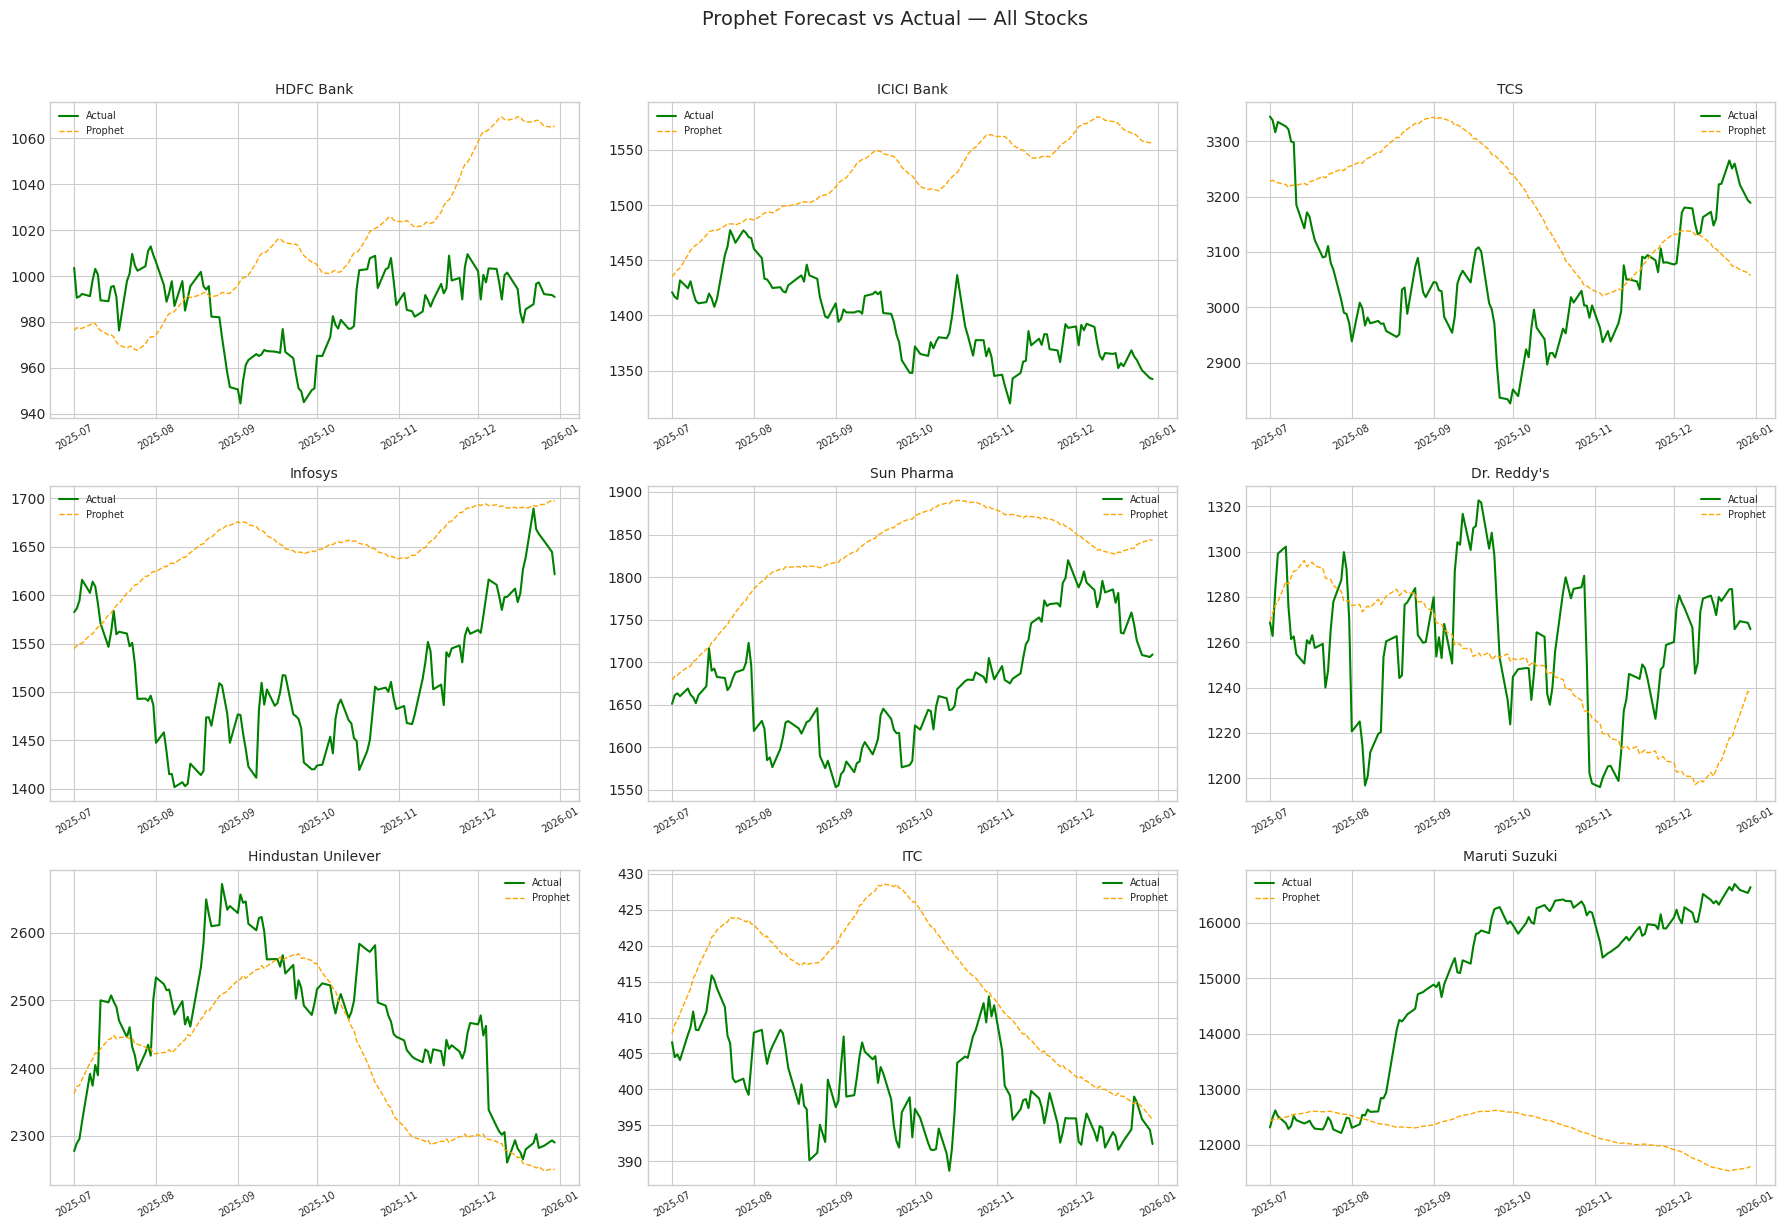

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
for i, (ticker, pred) in enumerate(all_preds.items()):
    if i >= 9: break
    ax = axes[i]
    actual = processed[ticker]["test"]
    ax.plot(actual, label="Actual", color="green", linewidth=1.5)
    ax.plot(pred, label="Prophet", color="orange", linewidth=1, linestyle="--")
    ax.set_title(STOCK_UNIVERSE.get(ticker, ticker), fontsize=10)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.legend(fontsize=7)
plt.suptitle("Prophet Forecast vs Actual — All Stocks", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
"We observed that Prophet failed significantly (MAPE ~5.7%) compared to ARIMA "
"(MAPE ~0.8%). This proves that for Indian equity markets, simpler statistical"
" models that focus on 'Last Price Momentum' (ARIMA) are far superior to complex seasonal models "
"(Prophet) which try to force artificial cycles onto random stock movements."